# Consumer Complaint Classifier — Product Triage

Multi-class text classification of real CFPB consumer-finance complaints, framed as an auto-triage tool that routes each complaint to the right product team. Built with a classical NLP pipeline (TF-IDF + Logistic Regression).

**Author:** Manzoor Syiemlieh — 7+ years handling disputes & complaints at PayPal.

In [8]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

[nltk_data] Downloading package stopwords to D:\Data\ML_Cache\nltk...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to D:\Data\ML_Cache\nltk...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to D:\Data\ML_Cache\nltk...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1. Load the data

CFPB Consumer Complaint Database — keep only the product label and the free-text narrative, and drop rows with no narrative.

In [9]:
import pandas as pd

# load only the two columns we need, drop rows with no narrative
df = pd.read_csv("data/complaints.csv",
                 usecols=["Product", "Consumer complaint narrative"],
                 low_memory=False)

df = df.dropna(subset=["Consumer complaint narrative"])
df = df.rename(columns={"Consumer complaint narrative": "narrative"})

print(df.shape)
print(df["Product"].value_counts())

(3802016, 2)
Product
Credit reporting or other personal consumer reports                             1670367
Credit reporting, credit repair services, or other personal consumer reports     807501
Debt collection                                                                  429801
Checking or savings account                                                      180573
Mortgage                                                                         143991
Credit card                                                                      120875
Money transfer, virtual currency, or money service                               117636
Credit card or prepaid card                                                      108683
Student loan                                                                      61479
Vehicle loan or lease                                                             51241
Credit reporting                                                                  31587
Payday loan

## 2. Consolidate products into a clean label set

The raw `Product` field has many overlapping names; map them into 7 product groups.

In [10]:
# Inspect first, THEN write your own mapping based on what you actually see:
df["Product"].value_counts()

product_map = {
    # --- examples; adjust to the exact strings in YOUR file ---
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting or other personal consumer reports": "Credit reporting",
    "Debt collection": "Debt collection",
    "Mortgage": "Mortgage",
    "Credit card or prepaid card": "Card",
    "Credit card": "Card",
    "Prepaid card": "Card",
    "Checking or savings account": "Bank account",
    "Bank account or service": "Bank account",
    "Student loan": "Student loan",
    "Money transfer, virtual currency, or money service": "Money transfer",
    # ...map the rest, or drop tiny/ambiguous ones
}
df["label"] = df["Product"].map(product_map)
df = df.dropna(subset=["label"])           # drop unmapped
print(df["label"].value_counts())

label
Credit reporting    2477868
Debt collection      429801
Card                 240716
Bank account         195456
Mortgage             143991
Money transfer       117636
Student loan          61479
Name: count, dtype: int64


## 3. Text preprocessing

Lowercase, drop CFPB `xxxx` redactions and numbers, strip punctuation, tokenize, remove stopwords, and lemmatize.

In [11]:
import re, string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP = set(stopwords.words("english"))
LEM = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"x{2,}", " ", text)        # drop CFPB xxxx redactions
    text = re.sub(r"\d+", " ", text)          # drop numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [LEM.lemmatize(t) for t in tokens if t not in STOP and len(t) > 2]
    return " ".join(tokens)

## 4. Balance the classes by sampling

"Credit reporting" dominates (2.4M rows), so sample up to 10,000 per class. A balanced set means macro-F1 reflects every product, not just the largest one.

In [12]:
# keep at most 10,000 rows per class -> small frame instead of 3.8M
df = df.groupby("label", group_keys=False).apply(
    lambda g: g.sample(min(len(g), 10000), random_state=42)
).reset_index(drop=True)
print(df.shape)

(70000, 3)


## 5. Clean the text and cache it

Apply the cleaner to the sampled data and save, so later runs skip re-cleaning.

In [13]:
df["clean"] = df["narrative"].apply(clean_text)
df[["clean", "label"]].to_csv("data/cleaned.csv", index=False)
print("cleaned and saved")

cleaned and saved


## 6. Class balance check

<Axes: ylabel='label'>

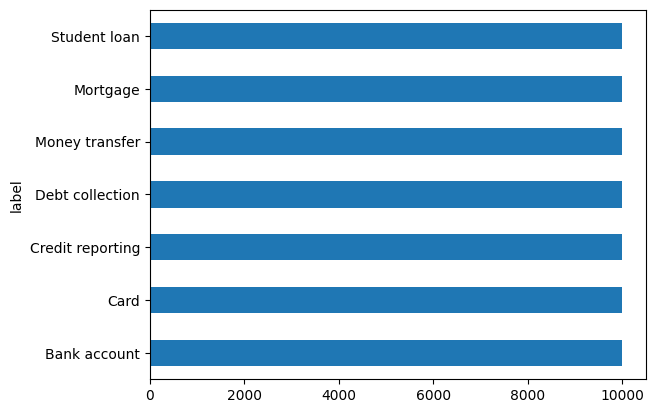

In [14]:
df["label"].value_counts().plot(kind="barh")

## 7. Train/test split — before vectorizing

Split first, then fit TF-IDF on the training text only, so no test-set vocabulary leaks into training.

In [15]:
from sklearn.model_selection import train_test_split

X = df["clean"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

## 8. TF-IDF vectorization

Convert text to weighted term features (unigrams + bigrams). Fit on train, transform test.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=5, max_df=0.9)
X_train_v = tfidf.fit_transform(X_train)
X_test_v  = tfidf.transform(X_test)
print(X_train_v.shape)

(56000, 20000)


## 9. Train the classifier

Logistic Regression with balanced class weights — a strong, interpretable baseline for sparse text features.

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_v, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## 10. Evaluation — macro-F1

Classes are balanced here, but macro-F1 (equal weight per class) is the honest metric for a multi-class triage tool.

In [18]:
from sklearn.metrics import classification_report, f1_score

pred = model.predict(X_test_v)
print("Macro-F1:", round(f1_score(y_test, pred, average="macro"), 4))
print(classification_report(y_test, pred))

Macro-F1: 0.8597
                  precision    recall  f1-score   support

    Bank account       0.78      0.82      0.80      2000
            Card       0.83      0.81      0.82      2000
Credit reporting       0.83      0.86      0.84      2000
 Debt collection       0.82      0.82      0.82      2000
  Money transfer       0.87      0.84      0.85      2000
        Mortgage       0.94      0.94      0.94      2000
    Student loan       0.94      0.93      0.93      2000

        accuracy                           0.86     14000
       macro avg       0.86      0.86      0.86     14000
    weighted avg       0.86      0.86      0.86     14000



## 11. Interpretability — top words per class

The model's coefficients show which words drive each product class — evidence it learned meaningful signal, not noise.

In [19]:
import numpy as np
feature_names = np.array(tfidf.get_feature_names_out())

for i, cls in enumerate(model.classes_):
    top = np.argsort(model.coef_[i])[-10:]
    print(cls, "->", feature_names[top])

Bank account -> ['debit' 'saving' 'branch' 'chime' 'checking' 'overdraft' 'account'
 'deposit' 'fund' 'bank']
Card -> ['credit card' 'citi' 'discover' 'reward' 'interest' 'charge' 'amex'
 'synchrony' 'credit' 'card']
Credit reporting -> ['vehicle' 'inaccuracy' 'inquires' 'item' 'credit' 'report' 'transunion'
 'inquiry' 'equifax' 'experian']
Debt collection -> ['calling' 'collect' 'bill' 'call' 'credit' 'recovery' 'owed' 'owe'
 'collection' 'debt']
Money transfer -> ['venmo' 'app' 'cashapp' 'fund' 'transaction' 'coinbase' 'zelle'
 'transfer' 'money' 'paypal']
Mortgage -> ['refinance' 'cooper' 'insurance' 'property' 'foreclosure' 'modification'
 'loan' 'escrow' 'home' 'mortgage']
Student loan -> ['edfinancial' 'aidvantage' 'education' 'student loan' 'school' 'nelnet'
 'student' 'mohela' 'navient' 'loan']


## 12. Save the model

In [21]:
import joblib
joblib.dump(tfidf, "model/tfidf.joblib")
joblib.dump(model, "model/classifier.joblib")

['model/classifier.joblib']

## Results & notes

- **Macro-F1: 0.86** across 7 product classes (test set, 2,000 each).
- Top-words-per-class are domain-meaningful (e.g. Mortgage → escrow/foreclosure; Money transfer → venmo/zelle/paypal), confirming real learned signal.

**Limitations:** only complaints with a published narrative are modelled (a subset of the full database); "Credit reporting" was downsampled for class balance; TF-IDF ignores word order and meaning; PII is redacted as `xxxx`.

**Next steps:** word embeddings or a transformer model for semantic understanding.